# Этап 1 — данные и базовая метрика

Запись/загрузка чистой речи, синтез шума завода, программное смешение с контролируемым ОСШ (SNR), кратковременная оценка ОСШ и энергетический детектор речевой активности (VAD). Подробности — в `PLAN.md`, раздел «Этап 1».

In [1]:
import sys
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import soundfile as sf

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(PROJECT_ROOT))

from src.stage01_data_vad import (
    SAMPLERATE,
    load_or_record_speech,
    synth_factory_noise,
    mix,
    estimate_windowed_snr,
    energy_vad,
    save_timeline,
)

## 1. Речь

Если файл `data/samples/speech.wav` уже существует — загружается он. Иначе выполняется запись с микрофона на заданную длительность (нужна фраза с паузой внутри, чтобы VAD ниже было на чём показать разметку).

In [2]:
SPEECH_PATH = PROJECT_ROOT / "data" / "samples" / "speech.wav"
DURATION_S = 6.0

speech = load_or_record_speech(SPEECH_PATH, duration_s=DURATION_S, samplerate=SAMPLERATE)
print(f"Речь: {len(speech) / SAMPLERATE:.2f} с, {SAMPLERATE} Гц")

Речь: 6.00 с, 16000 Гц


## 2. Шум завода (синтетика)

Сумма гармоник (гул двигателей/вентиляторов), сглаженного широкополосного шума и случайных импульсов (пуассоновский поток) — см. `synth_factory_noise`.

In [3]:
noise = synth_factory_noise(duration_s=len(speech) / SAMPLERATE, samplerate=SAMPLERATE, seed=0)
print(f"Шум: {len(noise) / SAMPLERATE:.2f} с")

Шум: 6.00 с


## 3. Смешивание с контролируемым ОСШ

In [4]:
SNR_DB = -5.0

mixed, speech_used, noise_used = mix(speech, noise, snr_db=SNR_DB)

MIX_PATH = PROJECT_ROOT / "data" / "processed" / "mix.wav"
MIX_PATH.parent.mkdir(parents=True, exist_ok=True)
sf.write(MIX_PATH, mixed, SAMPLERATE)
print(f"Сохранено: {MIX_PATH}")

Сохранено: d:\файлы\Documents\разное\ВУЗ\4 год\обработка сигналов\voice-noise-suppression\data\processed\mix.wav


## 4. Кратковременная оценка ОСШ

Поскольку речь и шум смешивались программно, обе составляющие известны по отдельности — это и заменяет физический тестовый стенд (см. `PLAN.md`, «Ограничения и допущения»).

In [5]:
overall_snr_db = 10 * np.log10(np.mean(speech_used**2) / (np.mean(noise_used**2) + 1e-12))
print(f"Итоговый ОСШ смеси: {overall_snr_db:.2f} дБ (целевой: {SNR_DB:.2f} дБ)")

times, snr_curve = estimate_windowed_snr(speech_used, noise_used, samplerate=SAMPLERATE)
print(
    f"Кратковременный ОСШ: медиана {np.median(snr_curve):.1f} дБ, "
    f"мин {np.min(snr_curve):.1f} дБ (паузы), макс {np.max(snr_curve):.1f} дБ (активная речь)"
)

Итоговый ОСШ смеси: -5.00 дБ (целевой: -5.00 дБ)
Кратковременный ОСШ: медиана -29.0 дБ, мин -35.0 дБ (паузы), макс 9.6 дБ (активная речь)


## 5. Энергетический VAD

Базовый вариант с фиксированным порогом (адаптивный порог — задача этапа 7).

In [6]:
timeline = energy_vad(mixed, samplerate=SAMPLERATE)

TIMELINE_PATH = PROJECT_ROOT / "data" / "processed" / "vad_timeline.json"
save_timeline(timeline, TIMELINE_PATH)
print(f"VAD-сегментов: {len(timeline)}. Сохранено: {TIMELINE_PATH}")
timeline

VAD-сегментов: 15. Сохранено: d:\файлы\Documents\разное\ВУЗ\4 год\обработка сигналов\voice-noise-suppression\data\processed\vad_timeline.json


[{'start': 0.0, 'end': 0.12, 'label': 'silence'},
 {'start': 0.12, 'end': 0.16, 'label': 'speech'},
 {'start': 0.16, 'end': 0.32, 'label': 'silence'},
 {'start': 0.32, 'end': 0.38, 'label': 'speech'},
 {'start': 0.38, 'end': 0.4, 'label': 'silence'},
 {'start': 0.4, 'end': 0.5, 'label': 'speech'},
 {'start': 0.5, 'end': 0.51, 'label': 'silence'},
 {'start': 0.51, 'end': 0.53, 'label': 'speech'},
 {'start': 0.53, 'end': 1.05, 'label': 'silence'},
 {'start': 1.05, 'end': 1.06, 'label': 'speech'},
 {'start': 1.06, 'end': 1.07, 'label': 'silence'},
 {'start': 1.07, 'end': 1.08, 'label': 'speech'},
 {'start': 1.08, 'end': 1.21, 'label': 'silence'},
 {'start': 1.21, 'end': 1.22, 'label': 'speech'},
 {'start': 1.22, 'end': 5.98, 'label': 'silence'}]

## 6. Визуализация

Сохранено: d:\файлы\Documents\разное\ВУЗ\4 год\обработка сигналов\voice-noise-suppression\results\stage01_waveform_vad.png


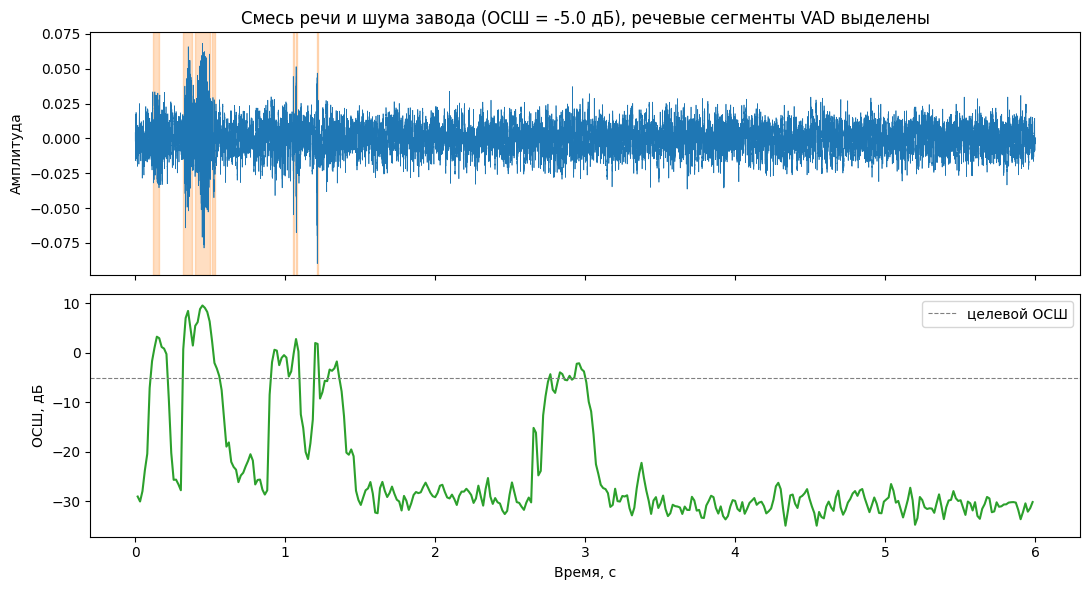

In [7]:
t_axis = np.arange(len(mixed)) / SAMPLERATE

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(11, 6), sharex=True)

ax1.plot(t_axis, mixed, linewidth=0.5, color="tab:blue")
for seg in timeline:
    if seg["label"] == "speech":
        ax1.axvspan(seg["start"], seg["end"], color="tab:orange", alpha=0.25)
ax1.set_ylabel("Амплитуда")
ax1.set_title(f"Смесь речи и шума завода (ОСШ = {SNR_DB:.1f} дБ), речевые сегменты VAD выделены")

ax2.plot(times, snr_curve, color="tab:green")
ax2.axhline(SNR_DB, color="gray", linestyle="--", linewidth=0.8, label="целевой ОСШ")
ax2.set_xlabel("Время, с")
ax2.set_ylabel("ОСШ, дБ")
ax2.legend()

fig.tight_layout()

RESULTS_PATH = PROJECT_ROOT / "results" / "stage01_waveform_vad.png"
RESULTS_PATH.parent.mkdir(parents=True, exist_ok=True)
fig.savefig(RESULTS_PATH, dpi=150)
print(f"Сохранено: {RESULTS_PATH}")
plt.show()